# EE / CprE / CybE 3250: Machine Learning for Electrical, Computer, and Cybersecurity Engineering
## Lab-03: Neural Networks for Classification
> *[Note from your instructor: in this lab we will be learning how to perform classification on multiple ECpE-relevant datasets. Similar to the pior lab, you will be gaining experience with several important concepts used throughout the rest of the course, including understanding the relationship between regression and classification, softmax functions, handling images as a separate category of inputs to a neural network, and some of the basic building blocks of multilayer network architectures. Work with your partner over the next two weeks to follow a step-by-step example, adapt this from-scratch example on an image classification dataset, and utilize higher-level framework functionality to develop your own implementation of classification. As before, collaborative learning is encouraged, as is the use of generative AI to assist with debugging coding challenges, as long as the answers to all conceptual questions are intellectually your own. Team learning is always encouraged, as long as the end product is intellectually your own. You will be assessed based on a combination of lab preparation (PreLab), answers to programming and conceptual questions (Lab), and demonstration of understanding (PostLab).]*

**Names:** 

**Group Name:**



### 0. Prelab
Please read through this entire document and answer the questions at the end under the “Prelab Questions” section header. These are due and will be checked at the beginning of the lab – please post if you have any questions.


In [37]:
# Initial setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from d2l import torch as d2l

### 1. Introduction to the Classification Task

In the previous lab, we explored linear regression, where we designed and evaluated models that predict numerical values. Regression is appropriate when the goal is to make numerical predictions. In contrast, when the goal is to make *categorical* predictions (i.e., assigning data to a category), we turn to classification. 

In this lab, you will explore different applications of classification in machine learning. Classification can be used to answer questions such as:

1.) Assigning a data sample to a specific class (hard assignments)

2.) Estimating the probability that a data sample belongs to each class (soft assignments)

You will explore multiple datasets, including both tabular and image data, to understand how classification can be used to extract information and make predictions. 


- **Q1.1:** Brainstorm ways that classification could be used in your field (Electrical, Computer or Cybersecurity Engineering). How could it be used to make your work more efficient and effective?

- **A1.1:** Classification would be useful for quickly filtering or determining a particular input, such as object detection on a self driving car. It would be almost necessary for real-world work in which you are dealing with varied scenarios that you cannot realistically account for.

### 2. Exploring a Binary Classification Dataset

Conceptually, the simplest task we can perform with classification is *binary* classification, where each data sample is assigned to one of two classes. This can be viewed as predicting a "true" or "false" outcome, or any scenario with two distinct categories. 


For this purpose, we will start with the [TUANDROMD](https://archive.ics.uci.edu/dataset/813/tunadromd) dataset, whose data contains instances of Android applications that are labeled as either benign (0) or malware (1). While the labels are binary, the features are also binary; they are widely varying attributes/properties of the apps that determine whether they are malicious or not. For each feature, a value of 1 means the app contains that property, and 0 means it doesn't. The dataset is provided in the `data/` directory. As in the previous lab, we begin by loading the dataset and exploring its tabular features. 

Given the large number of features, you may find it helpful to load the `df1` DataFrame in Data Wrangler or open the .csv file in Excel to better visualize the dataset.

In [38]:
df1= pd.read_csv("data/TUANDROMD.csv")
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Columns: 242 entries, ACCESS_ALL_DOWNLOADS to Label
dtypes: int64(241), str(1)
memory usage: 8.3 MB


In [39]:
df1.head()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
0,0,0,0,0,0,0,0,0,0,1,...,1,1,1,0,0,0,0,0,1,malware
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,1,0,0,malware
2,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,malware
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,0,1,0,0,malware
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,malware


In [40]:
df1.describe()

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/content/pm/PackageManager;->getInstalledPackages,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute
count,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,...,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000
mean,0.000896,0.000896,0.004928,0.083333,0.006944,0.087814,0.022849,0.023746,0.000224,0.596326,...,0.051971,0.173163,0.245520,0.215950,0.091622,0.088710,0.056228,0.133065,0.013665,0.150090
std,0.029924,0.029924,0.070037,0.276416,0.083053,0.283055,0.149440,0.152272,0.014967,0.490689,...,0.221994,0.378431,0.430443,0.411526,0.288524,0.284356,0.230387,0.339682,0.116108,0.357199
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


This dataset requires some preprocessing before it can be used for classification. Consider the Label column, which is the target the model will predict. Currently, it contains the string values "goodware" and "malware". These must be converted to numeric values (0 and 1, respectively), since the model outputs numerical predictions.

- **Q2.1:** Map the string labels to the values 0 and 1. This can be done in 1 line. After printing these binary labels, what have you learned about the TUANDROMD dataset, and how might that impact how you load the data for training?

- **A2.1:** After accidentally converting them all into 1's and then attempting to use map() I succeeded in reclassifying. After that and rerunning the describe cell I noticed that the average is around 0.8 which means there is likely an inherent bias towards malware in this dataset.

In [41]:
# Code for Q2.1 here. Convert the "Label" column to binary values (0 for goodware, 1 for malware) and print the resulting column.
# YOUR CODE STARTS HERE
df1['Label'] = df1['Label'].map({'goodware': 0, 'malware': 1})
# YOUR CODE ENDS HERE

print(df1['Label'])

0       1
1       1
2       1
3       1
4       1
       ..
4459    0
4460    0
4461    0
4462    0
4463    0
Name: Label, Length: 4464, dtype: int64


- **Q2.2:** Update the code block below to plot a histogram to visualize how the two classes are balanced. Briefly reflect on the class distribution you see, and how you anticipate it could effect training. 

- **A2.2:** The split of malware to goodware is skewed heavily towards malware.

(0.0, 4099.75)

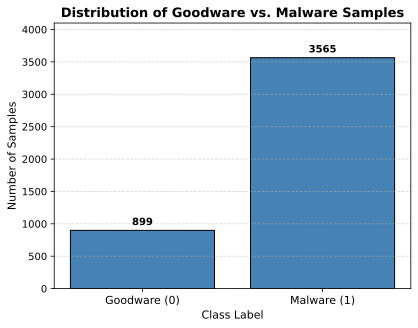

In [42]:
# Use plt.hist to display a histogram of the "Label" column, showing the distribution of goodware and malware samples. 
# Set the number of bins to 2

# YOUR CODE STARTS HERE
#plt.hist(df1['Label'].to_numpy(), bins=2) original, then used genAI to spruce it up

# YOUR CODE STARTS HERE
# Plot histogram with 2 bins, bar spacing, and borders
counts, bins, patches = plt.hist(
    df1['Label'].to_numpy(),
    bins=2,
    rwidth=0.8,
    color='steelblue',
    edgecolor='black'
)

# Align tick labels with the center of each bin (0.25 and 0.75)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, ['Goodware (0)', 'Malware (1)'], fontsize=11)

# Annotate sample counts on top of each bar
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        count + 50,
        f'{int(count)}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

# Formatting
plt.title('Distribution of Goodware vs. Malware Samples', fontsize=13, fontweight='bold')
plt.xlabel('Class Label', fontsize=11)
plt.ylabel('Number of Samples', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(counts) * 1.15)  # Leave headroom for labels
# YOUR CODE ENDS HERE
# YOUR CODE ENDS HERE

For training, the model should use all columns except the label column as input features. These features will be used to predict the label. 

- **Q2.3:** Update the `df1` DataFrame by excluding the label column and converting all remaining values to numeric. If a value cannot be converted, replace it with NaN. One option is to use the Pandas [to_numeric](https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html) to convert arguments to numeric types, with the option `errors='coerce'` to force NaN. Briefly describe how your code works below.

- **A2.3:** From df1, it drops the column "Label" and then it stores the other features into feature_cols. pd.to_numeric converts all of the values of the features into a numeric value. A NAN implies it cannot be converted into a numeric value. The describe() function prints them out into the notebook.


In [43]:
# Code for Q2.3 here. Store a subset of df1 as "feature_cols" and convert all data to numeric, replacing with "NaN" if impossible.
# YOUR CODE STARTS HERE
feature_cols = df1.drop(columns='Label').columns
print(feature_cols)
df1[feature_cols] = df1[feature_cols].apply(pd.to_numeric, errors='coerce')
df1.describe()
# YOUR CODE ENDS HERE


Index(['ACCESS_ALL_DOWNLOADS', 'ACCESS_CACHE_FILESYSTEM',
       'ACCESS_CHECKIN_PROPERTIES', 'ACCESS_COARSE_LOCATION',
       'ACCESS_COARSE_UPDATES', 'ACCESS_FINE_LOCATION',
       'ACCESS_LOCATION_EXTRA_COMMANDS', 'ACCESS_MOCK_LOCATION',
       'ACCESS_MTK_MMHW', 'ACCESS_NETWORK_STATE',
       ...
       'Landroid/content/pm/PackageManager;->getInstalledPackages',
       'Landroid/telephony/TelephonyManager;->getLine1Number',
       'Landroid/telephony/TelephonyManager;->getNetworkOperator',
       'Landroid/telephony/TelephonyManager;->getNetworkOperatorName',
       'Landroid/telephony/TelephonyManager;->getNetworkCountryIso',
       'Landroid/telephony/TelephonyManager;->getSimOperator',
       'Landroid/telephony/TelephonyManager;->getSimOperatorName',
       'Landroid/telephony/TelephonyManager;->getSimCountryIso',
       'Landroid/telephony/TelephonyManager;->getSimSerialNumber',
       'Lorg/apache/http/impl/client/DefaultHttpClient;->execute'],
      dtype='str', length=241)

,ACCESS_ALL_DOWNLOADS,ACCESS_CACHE_FILESYSTEM,ACCESS_CHECKIN_PROPERTIES,ACCESS_COARSE_LOCATION,ACCESS_COARSE_UPDATES,ACCESS_FINE_LOCATION,ACCESS_LOCATION_EXTRA_COMMANDS,ACCESS_MOCK_LOCATION,ACCESS_MTK_MMHW,ACCESS_NETWORK_STATE,...,Landroid/telephony/TelephonyManager;->getLine1Number,Landroid/telephony/TelephonyManager;->getNetworkOperator,Landroid/telephony/TelephonyManager;->getNetworkOperatorName,Landroid/telephony/TelephonyManager;->getNetworkCountryIso,Landroid/telephony/TelephonyManager;->getSimOperator,Landroid/telephony/TelephonyManager;->getSimOperatorName,Landroid/telephony/TelephonyManager;->getSimCountryIso,Landroid/telephony/TelephonyManager;->getSimSerialNumber,Lorg/apache/http/impl/client/DefaultHttpClient;->execute,Label
count,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,...,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000,4464.000000
mean,0.000896,0.000896,0.004928,0.083333,0.006944,0.087814,0.022849,0.023746,0.000224,0.596326,...,0.173163,0.245520,0.215950,0.091622,0.088710,0.056228,0.133065,0.013665,0.150090,0.798611
std,0.029924,0.029924,0.070037,0.276416,0.083053,0.283055,0.149440,0.152272,0.014967,0.490689,...,0.378431,0.430443,0.411526,0.288524,0.284356,0.230387,0.339682,0.116108,0.357199,0.401083
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Now that we have potentially added more NaNs to the dataframe, its time to deal with them. NaNs are dealt with on a case-by-case basis; here, we simply drop them.

In [44]:
#Drop all NaNs
df1 = df1.dropna()

You may notice that the feature columns in the TUANDROMD dataset are not easily interpretable. They are derived from static analysis of Android APK files and represent attributes such as permissions, API calls, intents, and hardware usage. These features are encoded as vectors, with most values being binary. As a result, standard EDA techniques may need to be adjusted when analyzing this dataset.

A simple first step is to identify the most common features across the dataset. In some cases, reducing noise by selecting only frequently occurring features can improve model performance. This dataset contains 240 features; for this lab, we will use the 30 most frequent features to train our model. These features are visualized below.

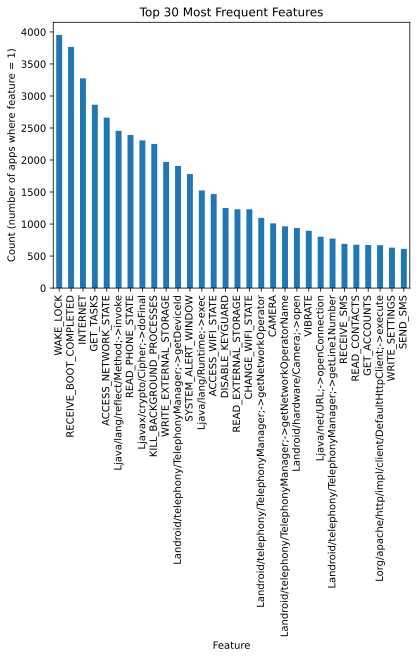

In [45]:
#New pandas series with counts of each feature column sorted from highest to lowest count
feature_freq = df1[feature_cols].sum().sort_values(ascending=False)

#Create Bar Graph
plt.figure()
feature_freq.head(30).plot(kind='bar')
plt.title("Top 30 Most Frequent Features")
plt.xlabel("Feature")
plt.ylabel("Count (number of apps where feature = 1)")
plt.xticks(rotation=90)
plt.show()

- **Q2.4:** To better understand the dataset, briefly research `WAKE_LOCK`, the most common feature. What does it represent, and why might it appear so frequently in Android applications?

- **A2.4:** WAKE_LOCK is a feature that allows an app to keep using the device's processor or screen when it would otherwise go to sleep. I would assume it would show up frequently to do background tasks, both malicious and benign.

Next, let's examine the frequency of each feature separately for malware and goodware samples. This will help identify which permissions, API calls, and other attributes are most indicative of malicious behavior.

/tmp/ipykernel_5438/756728532.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


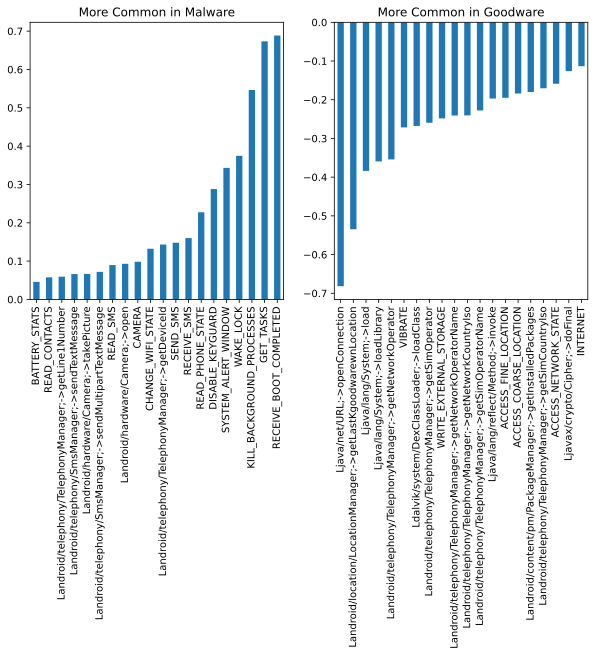

In [46]:
malware = df1[df1['Label'] == 1]
goodware = df1[df1['Label'] == 0]

diff = malware[feature_cols].mean() - goodware[feature_cols].mean()
diff = diff.sort_values()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# More common in malware
diff.tail(20).plot(kind='bar', ax=axes[0])
axes[0].set_title("More Common in Malware")
axes[0].tick_params(axis='x', rotation=90)

# More common in goodware
diff.head(20).plot(kind='bar', ax=axes[1])
axes[1].set_title("More Common in Goodware")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Note that the graph on the right is inverted, with the most frequent features appearing at the bottom. This is a standard technique for creating back-to-back bar charts. The values themselves are not negative; the axis is adjusted to visually flip the chart.

- **Q2.5:** Determine the most frequently occuring malware sample feature, and briefly research it. What does this permission allow, and why might it be strongly associated with malicious applications?

- **A2.5:** RECEIVE_BOOT_COMPLETED, this allows an app to run code immediately upon booting up. It's likely that malicous applications, such as a keylogger, would need to run in the background at all times including immediately after boot.

### 3. Working with the D2L Framework


Now that we have explored and attempted to understand our dataset, we can begin setting up our classes using the D2L framework. We will start by creating a class that handles the loading and training / validation split of our malware dataset. The code for this should look similar to the `BuildingEnergyEfficiencyData` class (and others) from Lab-02, with two key differences:

1.) You won't need to scale the features, as these are all binary values

2.) Our dataloader will need to randomly select from the DataFrame to get a representive sample of values in the training and validation datasets. 

- **Q3.1:** Finish the `__init__` implementation below, creating `X`, `y`, and `num_train`. Don't forget to save them as attributes of the class using `self.`. You will likely need to use [`torch.unsqueeze()`](https://docs.pytorch.org/docs/2.13/generated/torch.unsqueeze.html) to `self.y` to make it compatible with our loss function to come - explain why this is the case. 

- **A3.1:** 

In [47]:
class MalwareDataset(d2l.DataModule):
    def __init__(self, malware_data_df, train_val_split=0.8, batch_size=32):
        super().__init__()
        self.save_hyperparameters()
        #Create a copy - this allows for reruns without effecting notebook's global state
        df = malware_data_df.copy()

        # Convert the labels in the "Label" column to binary values (0 for goodware, 1 for malware)
        df["Label"] = df["Label"].map({"goodware": 0, "malware": 1})


        #Grab the top 30 features
        feature_cols = df.columns.difference(['Label'])
        feature_freq = df[feature_cols].sum().sort_values(ascending=False)
        top_features = feature_freq.head(30).index

        #List Position perserves the natural order of the columns
        final_cols = list(top_features) + ['Label']
        df = df[final_cols]

        #Shuffle Entries
        df = df.sample(frac=1).reset_index(drop=True)

        # YOUR CODE STARTS HERE
        self.X = torch.tensor(df[top_features].to_numpy(), dtype=torch.float32)
        self.y = torch.unsqueeze(torch.tensor(df['Label'], dtype=torch.float32), dim=1)

        self.num_train = int(len(df) * train_val_split)
        self.num_val = len(df) - self.num_train
        # YOUR CODE ENDS HERE

@d2l.add_to_class(MalwareDataset)  #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.y), train, i)

Confirm that your implementation is functioning correctly by creating an object of type `MalwareData`, loading a batch of data, and visualizing that batch. Starting code for this part is provided below. 

- **Q3.2)\:** Plot a histogram of the output feature (`y`) returned after calling `.train_dataloader()`. Compare to the previously reviewed values of the corresponding feature from the initial exploratory data analysis. Should we have expected the bars to be of equal height? Why or why not? 

- **A3.2)\:** The porportions of goodware compared to the number of malware is about the same. No, we shouldn't have expected equal height as we selected at random, so we would expect a similar porportion as the whole dataset, which is unbalanced.

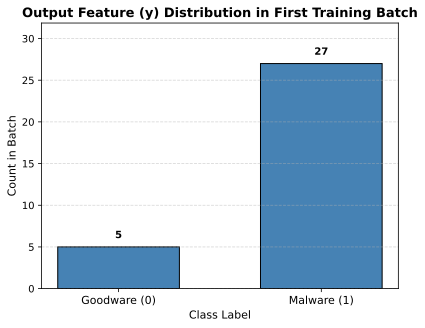

In [48]:
# Create a MalwareDataset object using the original dataset
malware_df= pd.read_csv("data/TUANDROMD.csv")
MalwareData = MalwareDataset(malware_df)

# Generate first iteration of a dataloader
X, y = next(iter(MalwareData.train_dataloader()))


# Plot this histogram of the output feature in the first training batch

# YOUR CODE STARTS HERE
y_arr = y.detach().cpu().numpy().flatten().astype(int)
# 2. Plot discrete bins centered on 0 and 1
counts, bins, patches = plt.hist(
    y_arr,
    bins=[-0.5, 0.5, 1.5],
    rwidth=0.6,
    color="steelblue",
    edgecolor="black",
)
# 3. Label ticks and add titles/axes matching the earlier EDA style
plt.xticks([0, 1], ["Goodware (0)", "Malware (1)"], fontsize=11)
plt.xlabel("Class Label", fontsize=11)
plt.ylabel("Count in Batch", fontsize=11)
plt.title(
    "Output Feature (y) Distribution in First Training Batch",
    fontsize=13,
    fontweight="bold",
)
plt.grid(axis="y", linestyle="--", alpha=0.5)
# 4. Annotate count values on top of each bar
for count, patch in zip(counts, patches):
    plt.text(
        patch.get_x() + patch.get_width() / 2,
        count + (max(counts) * 0.03 if max(counts) > 0 else 0.5),
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )
# 5. Set headroom above the tallest bar
plt.ylim(0, max(counts) * 1.18 if max(counts) > 0 else 5)
plt.show()
# YOUR CODE ENDS HERE


### 4. Binary Linear Classification from Scratch

With the dataset prepared, we can begin building our classification model. First, we briefly review the underlying mathematics.

Recall that the goal of a soft classifier model is to estimate the conditional probability for each class. To do this, the model produces one output per class, where each output is a linear function of the input features:

$$ o_i = x_1 w_{i1} + \cdots + x_d w_{ij} + b_i. $$

Similar to before, $x_i$ represents the inputs, $w_{ij}$ are the weights, and $b$ is the bias. The $o_i$ value represents the output for class $i$. As in linear regression, the weights capture the influence of each feature, and the bias represents the output when all inputs are zero. This formulation corresponds to a fully connected neural network layer, where each output depends on all inputs.

Instead of writing separate equations for each output, we can express this more compactly using vector and matrix notation:

$$\mathbf{o} = \mathbf{W} \mathbf{x} + \mathbf{b}.$$

Here, we have gathered all of our weight coefficients into a matrix $\mathbf{W}$ and all biases into our $\mathbf{b}$ vector. When implementing as a forward pass, we will typically process a batch of samples at a time, denoted by $\mathbf{X}$, leading to matrix-matrix product formulation:

$$\mathbf{O} = \mathbf{X} \mathbf{W} + \mathbf{b}.$$


It is important to note that these raw outputs ${o_i}$ cannot be interpreted as probabilities: they may be negative and do not necessarily sum to 1. To address this, we apply the $softmax$ function, which converts the outputs into valid probabilities:

$$\mathbf{\hat{y}}=\text{softmax(}\mathbf{o}\text{),    where }\hat{y}_i = \frac{\exp(o_i)}{\sum_j \exp(o_j)}$$

This transformation exponentiates each output and normalizes by the sum, ensuring all values are nonnegative on the interval $[0, 1]$ and sum to 1. In some contexts you will hear the $o_i$ terms referred to as $logits$ - the raw, unnormalized numerical scores output by a model before conversion to probabilities. 

This softmax can be either computed as part of the loss function (with some implementation tricks we will explore later in the lab), or directly on a row-by-row basis for the matrix $\mathbf{O}$:

$$\mathbf{\hat{Y}}=\text{softmax(}\mathbf{O}\text{)}.

- **Q4.1):** Say some constant scalar ${C}$ was added to every logit output ${o_i}$. How would the final probabilities be affected? Briefly justify your answer. 

- **A4.1):** The probablility would not be affected as the constant against all ${o_i}$ would all cancel out in softmax.

- **Q4.2):** How does exponentiation in the softmax affect the ratio of certain probabilities? Consider an outcome where one logit $o_1$ is 2, and another logit $o_2$ is 4. After the softmax, will the ratio of these values be double (as they currently are), less than double, or more than double? Will this strengthen or weaken the confidence of the model on its initial guess?

- **A4.2):** It would be more than double (at least if you are taking exp(o_2)/exp(o_1)) as exponents would grow exponentially rather than linearly. This make the model more confident and in this example the confidence of o_2 would be ~88% after plugging it into softmax.

- **Q4.3):** Implement `softmax()` in the space below, and briefly describe your code. 

- **A4.3):** Originally we used .sum() with no keep dim, which reduced it to a scalar, the following is revised for part 7. We first shift all values by max to prevent overflow from the exp calculation for part 7, then calculate all exponents with .exp(). Then we compute all exp divided by the sum of exponents (we keep dim to ensure it works for multiple outputs)

In [138]:
def softmax(O):
    O = O - O.max(dim=1, keepdim=True).values # ORiginially we did.sum which was fine until part 7 because we need multipl otuput classes
    exp_O = torch.exp(O) # Calculate all exponents
    return exp_O / exp_O.sum(dim=1, keepdim=True) # Softmax exp / exp_sum
    # YOUR CODE ENDS HERE


# Print the softmax function for some arbitrary 2D input
O = torch.rand((2, 5))
softmax_O = softmax(O)
print(softmax_O.flatten()) # print whole array
print(softmax_O.max()) # print highest confidence element
print(softmax_O.flatten().sum()) # should return 1
softmax_O, softmax_O.sum(1)


tensor([0.1791, 0.2677, 0.2448, 0.1833, 0.1251, 0.2020, 0.1669, 0.2427, 0.2109,
        0.1775])
tensor(0.2677)
tensor(2.0000)


(tensor([[0.1791, 0.2677, 0.2448, 0.1833, 0.1251],
         [0.2020, 0.1669, 0.2427, 0.2109, 0.1775]]),
 tensor([1.0000, 1.0000]))

Using the D2L framework, we declare a model object that defines and initializes values for $\mathbf{W}$ and $\mathbf{b}$. For now, we initialize $\mathbf{W}$ by generating random numbers from a normal distribution with mean of 0 and a standard deviation of `sigma=0.25`. This value gives our weights a healthy variety; our activation functions will have wider variance, keeping the gradients large. The bias $\mathbf{b}$ we set to 0. Complete the `LinearClassifier_v1` initialization below - your code should look effectively identical to the version from Lab-02, noting that our classifier has just the single prediction output. 

In [50]:
class LinearClassifier_v1(d2l.Module):
    """The linear classification model implemented from scratch."""    
    def __init__(self, num_inputs, num_outputs=1, lr=0.03, sigma=0.25):
        super().__init__()
        self.save_hyperparameters()

        # YOUR CODE STARTS HERE
        self.W = torch.nn.Parameter(torch.normal(0, sigma, (num_inputs, 1)))
        self.b = torch.nn.Parameter(torch.zeros(1))
        # YOUR CODE ENDS HERE


Those of you who were paying close attention might have discovered a pretty big issue with using `softmax()` on our binary classification data:
* We are predicting just a single true/false outcome (the application is either malware or goodware, never both or neither). Consequently, while we have 2 classes, we require only one output score. For this reason, we can treat $\mathbf{o}$ as ${o_0}$, just a scalar.
* Consequently when we calculate $\frac{\exp(o_i)}{\sum_j \exp(o_j)}$, there is no summation - the value will always be equal to 1. 
* So while the code for our function above is still going to eventually be useful when predicting multiple classes, we need to tweak the approach before proceeding!

Our solution for now is to instead apply a class of function called a *sigmoid*, which takes our arbitrary logit value and maps it to a value guaranteed to be in the range $[0, 1]$. There are many types of sigmoid functions - see [Wikipedia](https://en.wikipedia.org/wiki/Sigmoid_function) for a brief listing - for our purposes, a simple exponential version will suffice:

$$\text{sigmoid(}{x}\text{)} = \frac{1} {(1 + e^{-{x}})}$$





- **Q4.4):** Implement `sigmoid()` in the space below, and visualize the output over a range of input values. 

- **A4.4):** Done, the graph looks correct given it has the signature S shape with the middle being at the standard threshold of 0.5

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5438/2634990771.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel("$\sigma(x)$")


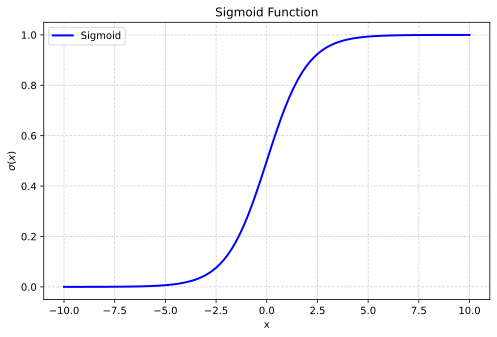

In [51]:
def sigmoid(x):
    return 1 / (1 + torch.exp(torch.neg(x)))

# Visualize the sigmoid function on a range of input values from -10 to 10
X = torch.linspace(-10, 10, 100)
sigmoid_X = sigmoid(X)

# YOUR CODE STARTS HERE 
# This does looks like the S graph of a sigmoid!
plt.figure(figsize=(8, 5))
plt.plot(X, sigmoid_X, label="Sigmoid", color="blue", linewidth=2)
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("$\sigma(x)$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()
# YOUR CODE ENDS HERE


To complete our linear model, we define the `forward()` method to perform our estimation $\mathbf{\hat{Y}}$ of the output $\mathbf{O}$ using our new `sigmoid()` function:

In [52]:
@d2l.add_to_class(LinearClassifier_v1)  #@save
def forward(self, X):
    return sigmoid(torch.matmul(X, self.W) + self.b)

We are now in a position to test out the functionality of our classifier model. We have to explicitly set the number of classes (1 in our current binary classification case). 

In [53]:
# Grab a batch to determine the number of input features
X, y = next(iter(MalwareData.train_dataloader()))
num_inputs = X.shape[1]

MalwareModel = LinearClassifier_v1(num_inputs, num_outputs=1, lr=0.03)

# Find the shape of the weights and biases for the model
MalwareModel.W.shape, MalwareModel.b.shape
print(MalwareModel.W)
print(MalwareModel.b)

Parameter containing:
tensor([[-0.1588],
        [-0.3358],
        [-0.0547],
        [-0.2075],
        [ 0.1229],
        [ 0.0391],
        [-0.0593],
        [ 0.2366],
        [-0.1442],
        [ 0.1688],
        [-0.4401],
        [ 0.1505],
        [-0.0213],
        [ 0.1494],
        [ 0.2469],
        [-0.2618],
        [-0.3808],
        [ 0.1533],
        [ 0.2988],
        [-0.0674],
        [ 0.7981],
        [-0.4179],
        [-0.0942],
        [-0.1592],
        [-0.3868],
        [ 0.5227],
        [ 0.2742],
        [ 0.2304],
        [ 0.2745],
        [ 0.1405]], requires_grad=True)
Parameter containing:
tensor([0.], requires_grad=True)


Confirm that a forward pass works as expected:

In [54]:
print(X.shape, y.shape, MalwareModel.type)   # using the initially loaded data from before

# Calculate y_hat using the .forward() method
y_hat1 = MalwareModel.forward(X)
print(y_hat1)

torch.Size([32, 30]) torch.Size([32, 1]) <bound method Module.type of LinearClassifier_v1()>
tensor([[0.7287],
        [0.7287],
        [0.2621],
        [0.3274],
        [0.5934],
        [0.2729],
        [0.7287],
        [0.4485],
        [0.4432],
        [0.2729],
        [0.4422],
        [0.3016],
        [0.4432],
        [0.7287],
        [0.7287],
        [0.2729],
        [0.5509],
        [0.7287],
        [0.4432],
        [0.3380],
        [0.4432],
        [0.3461],
        [0.4286],
        [0.4432],
        [0.6584],
        [0.4042],
        [0.4951],
        [0.7287],
        [0.2729],
        [0.5700],
        [0.4390],
        [0.4380]], grad_fn=<MulBackward0>)



Now that we have a working model, we have to define its loss function to assess its accuracy. For regression, we used the *squared error* formula to calculate the distance between the predicted and actual values. For classification tasks, we instead want to calculate how probable the actual classes are according to our model. While calculating this directly using a product of all the probabilities is possible, it is a little computationally awkward. Instead, we typically compute the negative of the log of these likelihood values. The resulting equation involves summation and is commonly called the *cross-entropy* loss:

$$l(\mathbf{y}, \mathbf{\hat{y}}) = -\sum_{j=1}^q y_j \log \hat{y}_j $$

This equation calculates the loss for a single sample $i$, and for each batch of $n$ samples, we can average the losses on the training data like before.

While all this seems a little arbitrary, the following questions will help with understanding how the calculation of the loss function becomes simplified in our binary classification case. 


- **Q4.5):** What is the range of our predicted labels $\mathbf{\hat{y}}$? What are the possible values for our actual labels $y_j$?

- **A4.5):** The range of our predicted values is (0,1) due to sigmoid (softmax in multiclass). The possible values for y_j is determined based on the amount of classes, but in this case it is either 0, 1.

- **Q4.6):** In the binary classification case (where $q=1$), given the range of $\mathbf{\hat{y}}$, what possible values can our loss function $l(\mathbf{y}, \mathbf{\hat{y}})$ have? Be specific.

- **A4.6):** It would be either 0 in the case that y_1 is 0 or ${log({\hat{y}})}$ if y_1 is 1.


Going back to our D2L framework, our next task is to implement this function, called `loss()`, which takes in the calculated / predicted values (${\hat{\mathbf{y}}}$, or `y_hat`) and the known values (${{\mathbf{y}}}$, or `y`), and returns the average $l$ across the predicted values. Note that there are going to be many ways to implement this code, some of which will only work for this binary classification case, and others that will be more general. The simplest approach, when $q=1$ for our single class cases, is to calculate the mean of what is known as the *binary cross-entropy* loss:

$$ l({y_i}, {\hat{y_i}}) = -(y_i \log \hat{y}_i + (1-y_i) \log (1 - \hat{y}_i))$$

Here, we are implicitly turning our single prediction ${\hat{{y_i}}}$ into its complement prediction $(1 - {\hat{{y_i}}})$, and computing the sum of the losses of each. 


- **Q4.6)\:** Given the range of ${y}$ and ${\hat{y}}$, what possible values can our new binary cross-entropy loss function $l({y_i}, {\hat{y_i}})$ have? What does a "correct" prediction look like? An "incorrect" prediction? Be specific. 

- **A4.6)\:** We kind of have two cases depending on the class of $y_i$, either l = $-log(\hat{y})$ or $-log(1-\hat{y})$. Those are the two possible values which are dependent on the prediction. A correct prediction would have a value closer to 1 inside the log, while a wrong prediction would be closer to 0 inside the log creating a larger loss value.

- **Q4.7)\:** Implement `loss()` below, and briefly explain your code for this part. 

- **A4.7)\:** It uses torches log function, but otherwise is a 1:1 implementation of the binary cross-entropy above. Except to actually calculate the whole loss we needed to take the mean via .mean() which caused issues briefly.

In [55]:
def binary_cross_entropy(y_hat, y):
    return -(y * torch.log(y_hat) + (1 - y) * torch.log(1-y_hat)).mean()

@d2l.add_to_class(LinearClassifier_v1)
def loss(self, y_hat, y):
    return binary_cross_entropy(y_hat, y)

We are almost ready to train our model. As before, we need to define an optimizer. Fortunately, Stochastic Gradient Descent (SGD) works well for classification, so we can reuse the same approach from Lab-02. Instead of implementing it from scratch again, we will use PyTorch’s built-in `torch.optim.SGD` to handle optimization.

In [56]:
@d2l.add_to_class(LinearClassifier_v1)  #@save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), self.lr)


We can also do the same for our training and validation loops. The code below is comparable to the Lab-02 implementation, with some additional accuracy metrics for debugging:

In [57]:
@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):

    #---TRAINING LOOP---
    self.model.train()
    #Training Variables to be accumulated 
    train_loss = 0.0
    train_correct = 0
    train_samples = 0 
    max_train = 0.0

    for batch in self.train_dataloader:

        # Unpack the loss, count of correct, and total number of items in batch
        loss, correct, n = self.model.training_step(self.prepare_batch(batch))

        print(f"Batch {self.train_batch_idx}: Loss = {loss.item():.4f}, Correct = {correct}/{n}")
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()

        # Accumulate Training Metrics
        train_loss += loss.item() * n
        train_correct += correct
        train_samples += n
        self.train_batch_idx += 1
        max_train = max(max_train, train_correct/train_samples)


    if self.val_dataloader is None:
        print(f"Epoch Summary -> Train Loss: {train_loss/train_samples:.4f} | Train Acc: {train_correct/train_samples:.4f}")
        return

    #---VALIDATION LOOP---
    self.model.eval()
    #Validation variables to be accumulated
    val_loss = 0.0
    val_correct = 0
    val_samples = 0 

    for batch in self.val_dataloader:

        with torch.no_grad():
            loss, correct, n = self.model.validation_step(self.prepare_batch(batch))
            val_loss += loss.item() * n
            val_correct += correct
            val_samples += n
            
        self.val_batch_idx += 1
    
    #Print out all metrics from the Epoch
    # Record one point per epoch for ProgressBoard
    self.model.board.xlabel = 'epoch'
    epoch = self.epoch + 1
    self.model.board.draw(epoch, train_loss / train_samples, 'train_loss')
    self.model.board.draw(epoch, train_correct / train_samples, 'train_acc')
    self.model.board.draw(epoch, val_loss / val_samples, 'val_loss')
    self.model.board.draw(epoch, val_correct / val_samples, 'val_acc')
    print(f"Epoch Summary -> Train Loss: {train_loss/train_samples:.4f} | Train Acc: {train_correct/train_samples:.4f} "
          f"|| Val Loss: {val_loss/val_samples:.4f} | Val Acc: {val_correct/val_samples:.4f} | Max train: {max_train:.4f}")

This handles all the whole training and validation loops. For training, it performs the forward pass, computes loss, and activates the optimizer. For validation, it drops the gradients and tracks the metrics of the model. Now, we need the test loop, so that we can view the accuracy of our model on new data that it wasn't trained on.

We could now fit and train our data, but we have't yet laid the framework for anything to be printed. We want to actually see our loss and accuracy outputs, so we need to define the step methods `training_step` and `vaidation_step` to define what happens per each batch of our `fit_epoch`. What these methods need to do is put all of the existing pieces into place for each iteration, such that we can print out the proper loss and accuracy for each. The code for each of these steps is provided below, make sure you analyze and understand what they are performing. 

- **Q4.9):** What line in the code block below converts our predictions from soft probabilities (values in the range [0-1] to hard probabilities (predictions of {0,1})? Briefly explain how that part of the code is working.  

- **A4.9):** This takes the predictions as probablities and the line `preds = (y_hat > 0.5).float()` converts them into hard probabilities as floats (either 0.0 or 1.0) by checking if they are above the threshold 0.5, which converts them to a Boolean and then converting it back to a float. Then it counts the number of correct below with y_true.

In [58]:
@d2l.add_to_class(LinearClassifier_v1)  #@save
def training_step(self, batch):
  X, y = batch
  y_hat = self(X)

  loss = self.loss(y_hat, y)

  preds = (y_hat > 0.5).float()
  #print(preds)

  y_true = y.float()
  correct = (preds == y_true).sum().item()
  n = y_true.numel()

  return loss, correct, n

@d2l.add_to_class(LinearClassifier_v1)  #@save
def validation_step(self, batch):
  with torch.no_grad():
    loss, correct, n = self.training_step(batch)

  return loss, correct, n


We are now ready to train our model on our data. Below, instantiate the hyperparameters and fit the model to our data.

Batch 0: Loss = 0.9480, Correct = 3/32
Batch 1: Loss = 0.8941, Correct = 4/32
Batch 2: Loss = 0.9054, Correct = 4/32
Batch 3: Loss = 0.8906, Correct = 7/32
Batch 4: Loss = 0.8243, Correct = 7/32
Batch 5: Loss = 0.8329, Correct = 6/32
Batch 6: Loss = 0.8055, Correct = 5/32
Batch 7: Loss = 0.8195, Correct = 10/32
Batch 8: Loss = 0.7130, Correct = 17/32
Batch 9: Loss = 0.7952, Correct = 10/32
Batch 10: Loss = 0.7724, Correct = 12/32
Batch 11: Loss = 0.7712, Correct = 18/32
Batch 12: Loss = 0.6704, Correct = 23/32
Batch 13: Loss = 0.6847, Correct = 19/32
Batch 14: Loss = 0.7401, Correct = 21/32
Batch 15: Loss = 0.6599, Correct = 27/32
Batch 16: Loss = 0.6936, Correct = 23/32
Batch 17: Loss = 0.6542, Correct = 24/32
Batch 18: Loss = 0.6249, Correct = 24/32
Batch 19: Loss = 0.5633, Correct = 26/32
Batch 20: Loss = 0.6508, Correct = 24/32
Batch 21: Loss = 0.6184, Correct = 23/32
Batch 22: Loss = 0.6056, Correct = 26/32
Batch 23: Loss = 0.5291, Correct = 28/32
Batch 24: Loss = 0.5255, Correct 

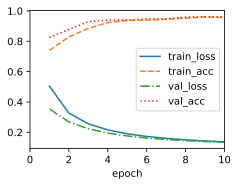

Batch 134: Loss = 0.3060, Correct = 25/32
Batch 135: Loss = 0.3455, Correct = 24/32
Batch 136: Loss = 0.2107, Correct = 29/32
Batch 137: Loss = 0.2385, Correct = 29/32
Batch 138: Loss = 0.3899, Correct = 25/32
Batch 139: Loss = 0.4532, Correct = 22/32
Batch 140: Loss = 0.3430, Correct = 25/32
Batch 141: Loss = 0.3753, Correct = 25/32
Batch 142: Loss = 0.3074, Correct = 27/32
Batch 143: Loss = 0.3978, Correct = 25/32
Batch 144: Loss = 0.2837, Correct = 28/32
Batch 145: Loss = 0.3115, Correct = 28/32
Batch 146: Loss = 0.3546, Correct = 25/32
Batch 147: Loss = 0.3153, Correct = 28/32
Batch 148: Loss = 0.3979, Correct = 24/32
Batch 149: Loss = 0.4016, Correct = 25/32
Batch 150: Loss = 0.3910, Correct = 24/32
Batch 151: Loss = 0.2896, Correct = 27/32
Batch 152: Loss = 0.3883, Correct = 26/32
Batch 153: Loss = 0.3531, Correct = 25/32
Batch 154: Loss = 0.4650, Correct = 26/32
Batch 155: Loss = 0.4865, Correct = 21/32
Batch 156: Loss = 0.3989, Correct = 27/32
Batch 157: Loss = 0.2293, Correct 

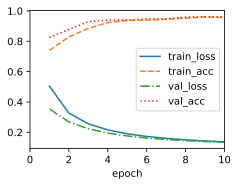

In [59]:
# Create a MalwareDataset object using the original dataset
malware_df= pd.read_csv("data/TUANDROMD.csv")
MalwareData = MalwareDataset(malware_df)

# Generate first iteration of a dataloader
X, y = next(iter(MalwareData.train_dataloader()))
num_inputs = X.shape[1]
MalwareModel = LinearClassifier_v1(num_inputs, num_outputs=1, sigma=0.25, lr=0.03)

# Instantiate the trainer, chosing a number of iterations (epochs)
# Then, fit the trainer with the data
model_trainer = d2l.Trainer(max_epochs = 10)
model_trainer.fit(MalwareModel, MalwareData)


**Q4.10):** How did our linear classifier perform? Did you expect the performance that we achieved? What was the highest training accuracy that was achieved?

**A4.10):** In the end we had a training accuracy of 95.35% and validation accuracy of 96.2% which is actually very good. The highest training accuracy was 95.37% which is just barely higher than the final training accuracy.

### 5. A Concise Implementation

Now that we've implemented this model from scratch once, we can again turn to a more concise implementation to illustrate how building a classification model would look like in practice. We'll call this version `LinearClassifier_v2`: 

In [60]:
from torch import nn
from torch.nn import functional as F

class LinearClassifier_v2(d2l.Module):
    def __init__(self, lr=0.03):
        super().__init__()
        self.save_hyperparameters()

        # For a simple linear binary classifier, we map the 30 input features down to 1 output
        self.net = nn.LazyLinear(1)
        
    def forward(self, X):
        return self.net(X)

Note that our forward pass in this concise version is only applying the weights and not the `sigmoid()` function from before. The reason we can do this is that PyTorch provides the functionality for us that combines both the sigmoid calculation and the cross entropy loss into a single stable function called `nn.BCEWithLogitsLoss()`. Here, we will also add back the built-in optimizer function `SGD()`. 

In [61]:
@d2l.add_to_class(LinearClassifier_v2)  #@save
def loss(self, y_hat, y):
    loss_fn = nn.BCEWithLogitsLoss(reduction='mean')
    return loss_fn(y_hat, y)

@d2l.add_to_class(LinearClassifier_v2)  #@save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), self.lr)

**Q5.1):** Review the PyTorch documentation for [BCEWithLogitsLoss](https://docs.pytorch.org/docs/2.12/generated/torch.nn.BCEWithLogitsLoss.html). Would adding `pos_weight` make sense for our malware classification task?

**A5.1):** It could make sense as pos_weight aims to adjust the loss function to account for imbalanced positive/negative samples, which this dataset is heavily biased towards malware. If we wanted to increase the precision we would have a `pos_weight < 1` but that comes at the tradeoff at decreasing the recall of the model.



Earlier, we defined `fit_epoch` from scratch in many lines of code; while D2L doesn't directly provide a fully implemented `fit_epoch`, we can write a much quicker version using higher-level APIs. The training loop logic is much the same, but we can replace our manual and tedious metric tracking using the d2l object `Accumulator`. Calling `d2l.Accumulator(3)` will track 3 metrics; total accumulated loss, total correct predictions from the model, and total data examples processed. Then, we call `metric.add` to push our data into the accumulator (the replacement for incrementing each variable).

Most importantly, we can use D2L's `d2l.ProgressBoard` to visualize the accuracy and loss of our model. We use `board.draw` to plot the curves for our training and validation accuracies and losses. 

In [69]:
@d2l.add_to_class(d2l.Trainer)
def fit_epoch(self):
    self.model.train()
    #Accumulator Object tracks [total_loss, total_correct, total_samples]
    metric = d2l.Accumulator(3)  
    
    for batch in self.train_dataloader:
        # Unpack the tuple returned by training_step
        loss, correct, n = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:
                self.clip_gradients(self.gradient_clip_val, self.model)
        self.optim.step()
        
        # Accumulate [total_loss, total_correct, total_samples]
        metric.add(float(loss.detach()) * n, correct, n)
        self.train_batch_idx += 1
        
    if hasattr(self, 'plot_flag') and self.plot_flag:
        #Draw curves for training loss and accuracy
        self.model.board.draw(self.epoch + 1, metric[0] / metric[2], 'train_loss')
        self.model.board.draw(self.epoch + 1, metric[1] / metric[2], 'train_acc')

    if self.val_dataloader is None:
        return
        
    # Switch to evaluation mode
    self.model.eval()
    val_metric = d2l.Accumulator(3) # Setup an accumulator for validation
    
    for batch in self.val_dataloader:
        with torch.no_grad():
            loss, correct, n = self.model.validation_step(self.prepare_batch(batch))
        # Accumulate validation loss and validation sample sizes
        val_metric.add(float(loss.detach()) * n, correct, n)
        self.val_batch_idx += 1
    
    if hasattr(self, 'plot_flag') and self.plot_flag:
        # Draw curves for validation loss and accuracy
        self.model.board.draw(self.epoch + 1, val_metric[0] / val_metric[2], 'val_loss')
        self.model.board.draw(self.epoch + 1, val_metric[1] / val_metric[2], 'val_acc')

    

Let's train and evaluate our concise model and compare it to the performance of our from-scratch one. We need to add our `train_step` and `validation_step` functions to our new concise model, and then we can use the same trainer by calling `trainer.fit`. These are the exact same as before copied and pasted, returning touples of loss, number of correct predictions, and total number of examples so the `fit_epoch` function above can unpack these and calculate accuracies. 

In [70]:
@d2l.add_to_class(LinearClassifier_v2)  #@save
def training_step(self, batch):
  X, y = batch
  y_hat = self(X)
  loss = self.loss(y_hat, y)

  preds = (y_hat > 0.5).float()
  y_true = y.float()
  correct = (preds == y_true).sum().item()
  n = y_true.numel()

  return loss, correct, n

@d2l.add_to_class(LinearClassifier_v2)  #@save
def validation_step(self, batch):

  with torch.no_grad():
    loss, correct, n = self.training_step(batch)

  return loss, correct, n


The following cell is incomplete. Here, instantiate the new `_v2` model and trainer, and train for `max_epochs=10` like before. There is also code provided to handle manually plotting the `ProgressBoard`; in future labs we can inherit the `d2l.Classifier` module to handle this, and many other components of the model, internally. For now, we need to explicitly link a `d2l.ProgressBoard` to our trainer. 

- **Q5.2:** How did the performance of the concise model compare to our from-scratch model? What was the highest train and validation accuracy percantage for each?

- **A5.2:** Its about the same, I would say within margin of error from entropy (random data sampling). Our training accuracy was 96% and our validation was also just about 96%.
This is within 1% difference of the original model

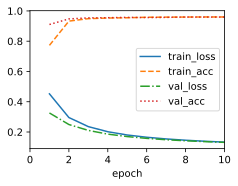


Final Training Loss:     0.1330
Final Validation Loss:   0.1314
----------------------------------------
Final Training Accuracy:   96.02%
Final Validation Accuracy: 95.97%


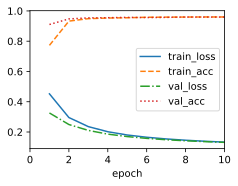

In [72]:
# Create a MalwareDataset object using the original dataset
malware_df= pd.read_csv("data/TUANDROMD.csv")
MalwareData_v2 = MalwareDataset(malware_df)

# Generate first iteration of a dataloader
X, y = next(iter(MalwareData.train_dataloader()))
num_inputs = X.shape[1]
MalwareModel_v2 = LinearClassifier_v2(lr=0.03)

# Instantiate the trainer, chosing a number of iterations (epochs)
# Then, fit the trainer with the data
model_trainer_v2 = d2l.Trainer(max_epochs = 10)


# This manually instantiates the matplotlib board and forces the flag to True
model_trainer_v2.plot_flag = True
#model_trainer_v2.board = d2l.ProgressBoard(xlabel='batches')
MalwareModel_v2.board.xlabel= 'epoch'
model_trainer_v2.fit(MalwareModel_v2, MalwareData)


# Function to print out final accuracies and loss values. We will be doing this fairly frequently, so save as a helper function
def print_model_results(board):
    # Print out final accuracies and loss values:
    final_tr_loss  = float(board.data['train_loss'][-1][1])
    final_tr_acc   = float(board.data['train_acc'][-1][1])
    final_val_loss = float(board.data['val_loss'][-1][1])
    final_val_acc  = float(board.data['val_acc'][-1][1])

    print("\n" + "="*40)
    print(f"Final Training Loss:     {final_tr_loss:.4f}")
    print(f"Final Validation Loss:   {final_val_loss:.4f}")
    print("-"*40)
    print(f"Final Training Accuracy:   {final_tr_acc * 100:.2f}%")
    print(f"Final Validation Accuracy: {final_val_acc * 100:.2f}%")
    print("="*40)

print_model_results(model_trainer_v2.model.board)

### 6. Working with Image Data

Classification on binary tabular data is a useful introduction, but one of the most influential applications we will study will involve image classification. Unlike tabular data, images require more complex methods to extract meaningful patterns and determine their category. As images increase in size, color complexity, and ambiguity, the classification task becomes more challenging.

We begin with the [MNIST database](https://en.wikipedia.org/wiki/MNIST_database), a simple image dataset containing 70,000 handwritten digits [0–9]. The dataset is pre-split into 60,000 training images and 10,000 testing images. Each image is 28×28 grayscale pixels, where each pixel value ranges from 0 to 255 and represents intensity. The labels correspond to the digit shown in each image [0–9].

This dataset is widely used as a baseline for machine learning tasks and is available directly through the torchvision package:

In [73]:
import torchvision
import torchvision.transforms as transforms

# Access dataset from torchvision
dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=None
)

print(dataset.data.shape)
print(dataset.data[0,4:10,4:10])
print(dataset.targets.shape)
print(dataset.targets[0:10])


100%|██████████| 9.91M/9.91M [00:00<00:00, 35.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 820kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 7.89MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 22.8MB/s]

torch.Size([60000, 28, 28])
tensor([[  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,  30,  36],
        [  0,   0,   0,  49, 238, 253],
        [  0,   0,   0,  18, 219, 253],
        [  0,   0,   0,   0,  80, 156]], dtype=torch.uint8)
torch.Size([60000])
tensor([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])


Above, we access the MNIST dataset. The 4 parameters we have to define for torchvision's MNIST dataset as you see above are:

`root`- The path to the folder where the raw data is stored.

`train`- Boolean that determines if the 60,000 image training subset, or the 10,000 image testing subset should be loaded.

`download`- Boolean that gives PyTorch the go-ahead to fetch files from the internet that aren't already in `root` folder.

`transform`- We will eventually need to use this parameter to specify a series of transformations on the data, so that the images will "fit" well into our classification pipeline. For now, we return the raw tensors that are downloaded and will process ourselves them next. 


- **Q6.1:** What is the most frequent image number in the first 100 images in the MNIST training dataset? The least frequent? Which pixel locations in the first 100 images have the most intensity on average? The least intensity? Use the following code block to explore answers to these questions. This MNIST dataset is designed so that you can use `.targets` to access the numerical labels (0-9), and `.data` to access the images themselves. These are tensors that you can grab and slice appropriately to answer these questions. 

- **A6.1:** 

Data_100 shape: torch.Size([100, 28, 28])
Most frequent in first 100: 1
1 appears 14 times
Least Frequent in first 100 5
5 appears 5 times


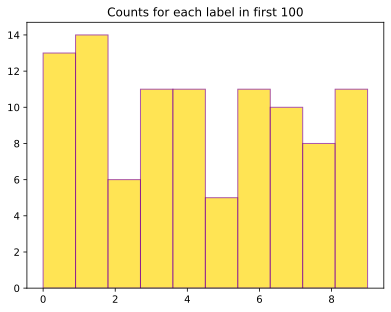

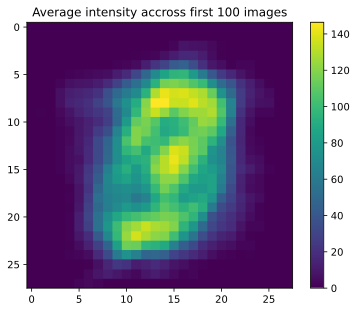

In [96]:
# Find the most frequent label in the first 100 training images  DONE & least

# Find the average intensity of the pixel at each position across the first 100 training images

# Plot a histogram of the output feature in the first training batch. Show all 10 classes in the histogram, and make sure to label the axes and title of the plot.

# Next, create a new figure, and calculate the average intensity of the pixel at each position across the first 100 training images and plot it as an image DONE



# YOUR CODE STARTS HERE
labels_100 = dataset.targets[0:100]
data_100 = dataset.data[0:100]
counts = torch.bincount(labels_100)
most_freq = torch.argmax(counts).item()
least_freq = torch.argmin(counts).item()

print(f"Data_100 shape: {data_100.shape}")

avg_intensity = np.average(data_100.numpy(), axis=0) # Find average intensity

print(f"Most frequent in first 100: {most_freq}")
print(f"{most_freq} appears {counts[most_freq].item()} times")
print("====================================================")
print(f"Least Frequent in first 100 {least_freq}")
print(f"{least_freq} appears {counts[least_freq].item()} times")

#print(f"Intensity shape: {avg_intensity}") # This outputs what appears to be slop... Dont uncomment

# Print histogram
plt.hist(labels_100, bins=10, edgecolor="purple", color="gold", alpha=0.67)
plt.title("Counts for each label in first 100")
plt.show()

# Print average intensity
plt.imshow(avg_intensity, cmap='viridis')
plt.colorbar()
plt.title("Average intensity accross first 100 images")
plt.show()

# YOUR CODE ENDS HERE


While we generally view our images using `matplotlib` or similar libraries, these individual MNIST images are small enough that we can get a decent visualization by using the built-in dataframe viewer, with a few tweaks. Let's look at the 2500th image in the training dataset using this approach:

In [97]:
# Print the shape of the 2500th training image, and then plot it as an image
im2500_t = dataset.data[2500]
print(dataset.targets[2500])

# Crop out the first few border rows and columns:
df = pd.DataFrame(im2500_t[2:24,6:23])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')


tensor(0)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,61,178,207,22,0,0,0,0,0,0,0,0
2,0,0,0,0,6,178,254,254,48,98,235,153,0,0,0,0,0
3,0,0,0,0,14,254,254,179,8,71,254,253,214,11,0,0,0
4,0,0,0,0,120,254,254,60,0,12,77,231,254,197,56,0,0
5,0,0,0,43,222,254,239,23,0,0,0,51,237,254,228,56,0
6,0,0,0,173,254,254,144,0,0,0,0,0,51,240,254,229,45
7,0,0,29,215,254,254,144,0,0,0,0,0,0,51,237,254,146
8,0,34,217,254,254,197,7,0,0,0,0,0,0,0,87,254,213
9,0,77,254,254,250,80,0,0,0,0,0,0,0,0,84,254,228


Likely if you were to write the number `0`, scan it at 28x28 pixel resolution, and magnify it, you would see something similarly imperfect looking! We can also determine what an "average" `3` looks like in the dataset: 

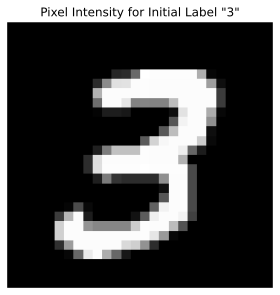

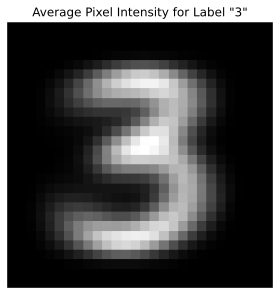

In [98]:
# Grab all training images that have a label of "3" and calculate the 
# average pixel intensity at each position.
threes = dataset.data[dataset.targets == 3].float()
avg_three = threes.mean(dim=0)
plt.imshow(threes[0], cmap='gray')
plt.title('Pixel Intensity for Initial Label "3"')
plt.axis('off')
plt.show()

plt.figure()
plt.imshow(avg_three, cmap='gray')
plt.title('Average Pixel Intensity for Label "3"')
plt.axis('off')
plt.show()

Finally, while we have been able to visualize and understand the MNIST data using the raw pixel information in the range $[0,255]$, it is going to complicate our classification task if we don't normalize our features (the pixel values). Otherwise, when training our model, any calculations using the weights might cancel when roughly an equal number of pixels are too dark or are too bright.

While we can use the `torchvision.transforms` library to automatically do this for us, updating the data we've downloaded to recenter each image at $\mu=0, \sigma=1$ can also be done manually in a few lines of code. 

- **Q6.2:** Implement the normalization of our image set as a function called `normalize_images()` that takes as input the images from our `dataset.data[]`, calculates the mean and standard deviation (across all images), and transforms the images so that the new mean is 0, and standard deviation is 1. Briefly explain your code below. 

- **A6.2:** First we calculate the average as the average across all pixels, then the standard deviation across all pixels. Then we get a "shifted" value which moves the average to (near, due to the nature of fp) 0 and then divide by the standard deviation. WE verified this with the print statements but commented them out. We also got confused as we were getting a 5 so we verified that the label is 5 and the labels and images didnt shift. 

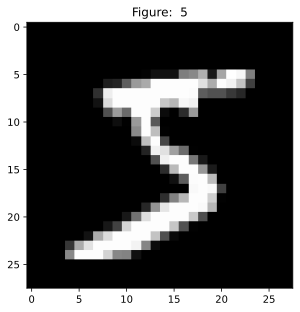

In [109]:
# Normalize the pixel intensity values to have a mean of 0, and a standard deviation of 1 across the entire training dataset. Then, plot the average pixel intensity for the normalized images that have a label of "3" again as an image.
def normalize_images(image_dataset):
    average = torch.mean(image_dataset.float())
    standard = torch.std(image_dataset.float()) #maybe an edge case if this is 0???
    # print(f"Avg: {average}")
    # print(f"Standard: {standard}")
    shifted = image_dataset - average
    # print(f"Shifted avg: {torch.mean(shifted)}") #close enough to 0
    normed = shifted / standard
    # print(f"Norm shape: {normed.shape}")
    # print(f"Norm avg: {torch.mean(normed)}")
    return normed

normalized_data = normalize_images(dataset.data)
plt.figure()
plt.title(f"Figure:  {dataset.targets[0]}") #sanity check as the output was 5???
plt.imshow(normalized_data[0], cmap='gray') # Figure should look the same as before, just with different pixel intensity values

Under the assumption that each of the pixels in our `28x28` image can be interpreted as $28\cdot28=784$ input features, we can define our D2L DataLoader for this MNIST image dataset by simply loading the data as before. There are a few new wrinkles:
* Unlike previously, we shouldn't directly set a `train_val_split` value. The number of training (`60000`) and validation (`10000`) images are already known. We can hard-code this or use the size of the datasets accordingly.
* We should normalize the data based on the mean and stddev of the training dataset. Our `normalize_images()` function will help here. 
* We are classifying our input images as one of 10 categories (values in the range $[0,9]$). For the binary classification case, we were fine with just a single output from the model. Now, we need 10 outputs, so we have to convert our target label data to what is known as a [One-hot](https://en.wikipedia.org/wiki/One-hot) encoding of each label. For example, a `0` label becomes `[1 0 0 0 0 0 0 0 0 0]`, `1` becomes `[0 1 0 0 0 0 0 0 0 0]`, etc. 


- **Q6.3:** Review the implementation of `MNISTDataset` below, and briefly answer the following questions. Where in the code do we flatten our 28x28 image to a 768x1 vector?  What is our `torch.empty_like` function doing? 

- **A6.3:** it is the `self.X = normalized_data.view(-1, 28*28)` section which flattens it down into 784x1 (technically 100000x784 but thats because of the number of images). `torch.empty_like` is not used (this is a typo in the question).

In [ ]:
class MNISTDataset(d2l.DataModule):
    def __init__(self, train_dataset, val_dataset, batch_size=32):
        super().__init__()

        # Create a new tensor to hold the combined training and validation data, and then normalize all the data 
        combined_img_data = torch.cat((train_dataset.data, val_dataset.data), dim=0)
        normalized_data = normalize_images(combined_img_data)

        self.X = normalized_data.view(-1, 28*28)
        print(self.X.shape)

        # the y values are a one-hot encoding of the labels, so we need to unsqueeze to add an extra dimension for the one-hot encoding
        encoded_labels = torch.nn.functional.one_hot(torch.cat((train_dataset.targets, val_dataset.targets), dim=0), num_classes=10)
        self.y = encoded_labels.float()
        print(self.y.shape)


        # Set the train and val sizes based on the size of the respective datasets
        num_train = train_dataset.data.shape[0]
        num_val = val_dataset.data.shape[0]

        print(num_train, num_val)
        self.save_hyperparameters() # Call this after defining num_train and num_val    
        


@d2l.add_to_class(MNISTDataset)  #@save
def get_dataloader(self, train):
    i = slice(0, self.num_train) if train else slice(self.num_train, None)
    return self.get_tensorloader((self.X, self.y), train, i)

Finally, let's confirm that we are able to use our `get_dataloader()` function to return back our images and labels as expected. Update this code below to visually the 16th image from our first batch of 32, and corresponding label:

torch.Size([70000, 784])
torch.Size([70000, 10])
60000 10000
torch.Size([32, 784]) torch.Size([32, 10])


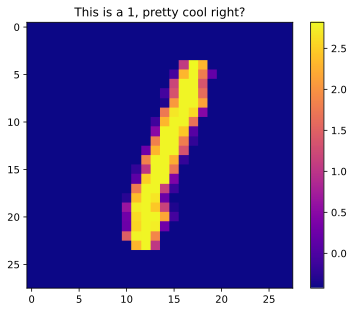

In [125]:
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True)
mnist_val = torchvision.datasets.MNIST(root='./data', train=False, download=True)

MNIST_Data = MNISTDataset(mnist_train, mnist_val, batch_size=32)

# Review how the first batch looks
X, y = next(iter(MNIST_Data.train_dataloader()))
print(X.shape, y.shape)

# YOUR CODE STARTS HERE
plt.imshow(X[15].reshape(28,28), cmap="plasma")
plt.title(f"This is a {torch.argmax(y[15])}, pretty cool right?")
plt.colorbar()
plt.show()
# YOUR CODE ENDS HERE


### 7. Linear Image Classification from Scratch

For the most part, since we are still using a single, fully-connected layer for performing classification, we do not have to make many adjustments to our from-scratch `LinearRegression_v1` model from before. We need to consider the following differences when compared to the binary classification case:
* We have 10 output classes, not 1 as before. Depending on how you implemented `LinearRegression_v1`, you may have to take that into account when initializing your weights and biases. 
* Since we have multiple output classes, we need to go back to our `softmax()` function vs our usage of `sigmoid()` to transform our logits into probabilities.
* Our loss function should be the full cross entropy equation, and not the special case of binary cross-entropy from before.
* Converting from soft probabilities to a class assignment will require finding the maximum value amongst the predicted probabilities.  

Let's take each modification in turn.

- **Q7.1)** Implement the `__init__` constructor for class `LinearRegression_v3` below, and describe what differences (if any) you made from the previous `LinearRegression_v1.__init__()`:

- **A7.1)** We had to change from a hardcoded 1 for num_outputs to num_outputs to output the 10 classes


In [131]:
class LinearClassifier_v3(d2l.Module):
    def __init__(self, num_inputs, num_outputs=1, lr=0.03, sigma=0.25):
        super().__init__()
        self.save_hyperparameters()

        # YOUR CODE STARTS HERE
        self.W = torch.nn.Parameter(torch.normal(0, sigma, (num_inputs, num_outputs)))
        self.b = torch.nn.Parameter(torch.zeros(num_outputs))

    # Keep the same SGD optimization    
    def configure_optimizers(self):
      return torch.optim.SGD(self.parameters(), self.lr)

Our forward pass should be similar to before, except now we are calculating the `softmax()` on our logits for each batch:

$$\mathbf{\hat{Y}}=\text{softmax(}\mathbf{O}\text{)}\text{, where}$$
$$\mathbf{O} = \mathbf{X} \mathbf{W} + \mathbf{b}\text{, and}$$
$$ \hat{y}_i = \frac{\exp(o_i)}{\sum_j \exp(o_j)}$$

Depending on how you previously implemented `softmax()` previously, that function should suffice for this step. Implement the `forward` pass for class `LinearRegression_v3` below. 

In [132]:
@d2l.add_to_class(LinearClassifier_v3)  #@save
def forward(self, X):
    return softmax(torch.matmul(X, self.W) + self.b)


Let's test that our forward pass works as intended before proceeding:



In [153]:
# We know the number of input features from the training data
X, y = next(iter(MNIST_Data.train_dataloader()))
num_inputs = X.shape[1]

MNIST_Model = LinearClassifier_v3(num_inputs, num_outputs=y.shape[1], lr=0.03)

# Find the shape of the weights and biases for the model
print(MNIST_Model.W.shape, MNIST_Model.b.shape)

y_hat1 = MNIST_Model.forward(X)
print(y_hat1)
print(f"Sanity: {torch.sum(y_hat1)} Should be batch size")



torch.Size([784, 10]) torch.Size([10])
tensor([[4.2165e-09, 2.4250e-09, 2.0603e-11, 2.2910e-11, 1.8250e-14, 9.1759e-12,
         9.9841e-01, 4.3241e-07, 2.3274e-11, 1.5863e-03],
        [1.3022e-01, 4.2341e-05, 1.3962e-04, 1.9781e-03, 1.3937e-06, 2.5356e-03,
         7.9474e-01, 4.3530e-02, 2.5548e-02, 1.2682e-03],
        [6.4943e-04, 1.6742e-02, 3.9208e-06, 7.4640e-03, 7.8203e-03, 2.9143e-02,
         3.3881e-02, 6.4117e-04, 1.0724e-02, 8.9293e-01],
        [7.5209e-02, 1.4279e-02, 3.3694e-03, 3.8907e-04, 4.6868e-08, 2.4197e-04,
         6.6607e-02, 3.1675e-03, 6.7082e-01, 1.6591e-01],
        [2.2785e-04, 1.1086e-07, 4.9225e-05, 2.3281e-05, 4.5123e-12, 5.5329e-07,
         1.8415e-04, 4.2527e-07, 6.6299e-06, 9.9951e-01],
        [3.3718e-04, 4.9272e-04, 1.6413e-04, 5.1623e-03, 8.7724e-02, 1.0257e-08,
         8.3454e-07, 1.8704e-01, 7.7407e-02, 6.4167e-01],
        [3.1383e-11, 3.2265e-06, 4.0401e-04, 1.1541e-07, 1.7458e-09, 3.4444e-10,
         1.0304e-09, 1.2473e-09, 2.9191e-04, 9

- **Q7.2)** This forward pass was implemented with completely randomized weights. Review the predicted outputs - for the 32 images that are classified in this batch, what labels (numbers) would they be predicted to be? Briefly defend your answer. 

- **A7.2)** They would likely be randomly predicted, but the prediction itself would be the max of the probability of the outputs (i.e. the largest label prediction). This is because all the values sum to 1.0 and as such there must exist a prediction that is the largest which is chosen as the final output label.


Our loss function needs to calculate the full cross-entropy between class predictions. From before, we compute the negative of the log of our likelihood values $\hat{y}_j$, scaled by the actual correct prediction for each class $y_j$:

$$l(\mathbf{y}, \mathbf{\hat{y}}) = -\sum_{j=1}^q y_j \log \hat{y}_j $$

- **Q7.3)** Implement function `cross_entropy()` and `loss()` below. Note that the "correct" (or at least most Pythonic, and likely most computationally efficient) approach would be use a [list comprehension](https://www.w3schools.com/python/python_lists_comprehension.asp) here. For whatever approach you do use, explain your implementation and how the terms of the cross-entropy equation are being computed. 

- **A7.3)** 

In [154]:
def cross_entropy(y_hat, y):
    return -(y * torch.log(y_hat)).sum(dim=1).mean()

@d2l.add_to_class(LinearClassifier_v3)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)


- **Q7.4)** For a randomized (arbitrary) prediction of an image's class, what would you expect the typical range of the `cross_entropy()` loss function to be? Either use the code block below to explore the answer to this question, or provide a more detailed arithmetic explanation. 

- **A7.4)** A randomized prediction of cross_entropy() would be 


In [156]:
# Test out the loss function with our initial prediction and labels
# YOUR CODE STARTS HERE
loss_1 = MNIST_Model.loss(y_hat=y_hat1, y=y)
print(f"Loss: {loss_1}")
# YOUR CODE ENDS HERE


Loss: 11.814889907836914


Finally, our training loop can look almost identical to before, with the final tweak that we determine the class assignment by finding the maximum value's index from our predictions $\hat{y}$:

In [ ]:
@d2l.add_to_class(LinearClassifier_v3)  #@save 
def training_step(self, batch):
    X, y = batch
    y_hat = self(X)

    # Compute our loss function using the model's loss method    
    loss = self.loss(y_hat, y)

    # Convert predictions to class indices
    preds = y_hat.argmax(dim=1).long()
    
    # Force targets to be integers and flatten shapes for safe comparison
    y_true = y.argmax(dim=1).long().view(-1)
    preds = preds.view(-1)

    # Our correct count is the number of times our predicted class matches the true class
    correct = (preds == y_true).sum().item()
    n = y_true.numel()

    return loss, correct, n

# Our validation step is the same as our training step, except we don't need to worry about gradients, 
# so we can wrap the whole thing in a torch.no_grad() context manager to be safe and efficient
@d2l.add_to_class(LinearClassifier_v3)  #@save
def validation_step(self, batch):
    with torch.no_grad():
        loss, correct, n = self.training_step(batch)
    return loss, correct, n

Let's put the dataloader, classifier model, and trainer together to see how they do:

In [ ]:
# Instantiate our dataloader
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, download=True)
mnist_val = torchvision.datasets.MNIST(root='./data', train=False, download=True)
MNIST_Data = MNISTDataset(mnist_train, mnist_val, batch_size=32)

X, y = next(iter(MNIST_Data.train_dataloader()))

# Create an instance of our model using the number of input features and output classes from our data
MNIST_model = LinearClassifier_v3(num_inputs=X.shape[1], num_outputs=y.shape[1], lr=0.01)

# Instantiate the trainer, chosing a number of iterations (epochs)
model_trainer_v3 = d2l.Trainer(max_epochs=20)
model_trainer_v3.plot_flag = True
model_trainer_v3.board = d2l.ProgressBoard(xlabel='batches')
model_trainer_v3.fit(MNIST_model, MNIST_Data)

print_model_results(model_trainer_v3.board)

Let's attempt to visualize what our weights look like for predicting our image classes.  

- **Q7.5)** Implement code in the following block that reads back the trained weights from our `MNIST_model` object, and visualizes the weights corresponding to detecting class labels as a 2 row by 5 column grid. If you are having trouble doing this for all classes, at the very least visualize the weights corresponding to label `7`. Describe your observations: do the values of these weights make some intuitive sense to you?

- **A7.5)** 

In [ ]:
# Read the weights back from the trained model, and reshape them into a 28x28 image for each output class. 
# Then, plot these weight images in a 2 row by 5 column grid, and set the title of each image to its corresponding class.

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


### 8. A Concise Implementation

While our previous implementation of the MNIST data loader class (`MNISTDataset`) was perfectly suitable for our purposes, for future image classification tasks, we will require more significant preprocessing of our data to make it more amenable for more advanced models than our single fully-connected layer. For a more concise implementation, we can chain together multiple pre-built transformations on our MNIST images. We'll call this class `MNISTDataset_v2` and we'll do the data downloading and processing at the same time:

In [ ]:
class MNISTDataset_v2(d2l.DataModule):
    def __init__(self, batch_size=32, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()

        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor(),
                                    transforms.Normalize(0.1307, 0.3081)]) 
        self.train = torchvision.datasets.MNIST(
            root='./data', train=True, transform=trans, download=True)
        self.val = torchvision.datasets.MNIST(
            root='./data', train=False, transform=trans, download=True)


@d2l.add_to_class(MNISTDataset_v2)  #@save
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)


Although it sounds simple, the `transforms.ToTensor()` is doing quite a bit of heavy lifting for us: it automatically converts the pixel values to the range `[0,1]`, and adds a channel dimension. We can then normalize using a chained call to `transforms.Normalize()` to adjust our mean and standard deviation.  

- **Q8.1)** The numbers `0.1307` and `0.3081` for the mean and standard deviation seem a little arbitrary. Reviewing our prior pre-processing of the MNIST dataset, how were these values derived? Be specific. 

- **A8.1)** 

For the model, we will use `nn.Sequential()` to chain together operations. Before we can use a linear layer, we need to flatten the dimensions of our data from `(batch_size, 1, 28, 28)` to `(batch_size, 784)`. Previously we did this manually via a `.reshape()` call, and now we will instead use PyTorch's `nn.Flatten()`, followed by our `LazyLinear`. 

Our `.forward()` method can be the same as our concise implementation before - we simply pass our inputs through the defined network to output raw logits. 

In [ ]:
class LinearClassifier_v4(d2l.Classifier):  #@save
    """The softmax regression model."""
    def __init__(self, num_outputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.LazyLinear(num_outputs))

    def forward(self, X):
        return self.net(X)

For the loss function, we can use `nn.CrossEntropyLoss`, which internally combines the softmax and multi-class cross entropy into one stable mathematical function. However, it somewhat bypasses the need to explicitly calculate softmax probabilities by using a trick known as "log-sum-exp". Mathematically it looks like:
$$\log(\hat{y}_i) = \log \left( \frac{e^{o_i}}{\sum_{j} e^{o_j}} \right) = o_i - \log \left( \sum_{j} e^{o_j} \right)$$

If you're interested in exploring further, the following academic publication provides a detailed overview: [link](https://academic.oup.com/imajna/article/41/4/2311/5893596). For our purposes, it is sufficient to know that by combining the cross-entropy and the softmax into a single step, we avoid potential numerical precision issues, and save on some computation as well, without any loss of accuracy. 

In [ ]:
@d2l.add_to_class(LinearClassifier_v4)
def loss(self, y_hat, y):
    loss_fn = nn.CrossEntropyLoss(reduction='mean')
    return loss_fn(y_hat, y)

We can use the default SGD optimizier and training and validation steps from before, since they will work with our new loss function and model output format without any modifications needed.

In [ ]:
@d2l.add_to_class(LinearClassifier_v4)  #@save 
def training_step(self, batch):
    X, y = batch
    y_hat = self(X)

    # Compute our loss function using the model's loss method    
    loss = self.loss(y_hat, y)

    # Convert predictions to class indices
    preds = y_hat.argmax(dim=1).long()
    
    # MNISTDataset_v2 returns class-index labels, so compare against y directly
    y_true = y.long().view(-1)
    preds = preds.view(-1)

    # Our correct count is the number of times our predicted class matches the true class
    correct = (preds == y_true).sum().item()
    n = y_true.numel()
    return loss, correct, n

@d2l.add_to_class(LinearClassifier_v4)  #@save
def validation_step(self, batch):
    with torch.no_grad():
        loss, correct, n = self.training_step(batch)
    return loss, correct, n

Let's train our last model; same protocol as before, and we will continue with the ProgressBoard approach for visualization now that we are very familiar with it. 

In [ ]:
# Instantiate the MNIST data module and the linear classifier after the custom step methods have been defined.
MNIST_Data2 = MNISTDataset_v2(batch_size=64)

MNIST_model2 = LinearClassifier_v4(num_outputs=10, lr=0.1)

# Fit the model and visualize training progress.
model_trainer_v4 = d2l.Trainer(max_epochs=10)
model_trainer_v4.plot_flag = True
model_trainer_v4.board = d2l.ProgressBoard(xlabel='batches')
model_trainer_v4.fit(MNIST_model2, MNIST_Data2)

print_model_results(model_trainer_v4.board)


Although you might have tweaked a hyperparameter or two in the transition from the from scratch to the concise version of the same model, likely your loss and accuracy numbers should be roughly the same as before. As a final step, let's actually use our model to review predictions on the validation set. 

- **Q8.2)** In the code block below, grab a batch of images from the MNIST validation set. Evaluate your model on these images, and plot one image that is correctly predicted, and one that is incorrectly predicted. What is your best guess as to why the one image was predicted incorrectly? 

- **A8.2)** 

In [ ]:
# Grab the next batch of validation data

# Evaluate the model on the data, and find the first correct and the first incorrect prediction

# Plot the correctly predicted image with label

# Plot the incorrectly predicted image with label

# YOUR CODE STARTS HERE

# YOUR CODE ENDS HERE


### Lab Submission
When you are ready to submit this assignment on Canvas, be sure to save this file first, then run the following command to generate the two files you'll need to upload for Canvas submission:

In [ ]:
!bash ../3250_create_submission.sh

### Prelab Questions

- **Q0.1)\:** A linear classifier can be applied to both tabular malware data and image data such as MNIST. In what ways are these problems similar, and in what ways are they different? Consider features, interpretability, dimensionality, and model assumptions.

- **A0.1)\:** These problems are similar as they are both classification, however in the malware dataset the feature inputs are much better defined comapred to the raw image inputs. The image inputs are much more difficult to properly do feature extration beyond basic pre processing, however the MNIST dataset is still relatively basic in this regard. In comparison the malware dataset where the features are already extracted. The largest difference is that the activation function will be different as the MNIST dataset and Malware dataset are multi-class and binary classification respectively.

In terms of dimensionality the malware has a smaller dimensionality, while the MNIST dataset gets flattened into WxH dims.

- **Q0.2)\:** How is binary classification different from multi-class classification? Consider the model output, modeling process, and challenges involved.


- **A0.2)\:** The main difference is instead of predicting between two classes (-1, 1 or 0, 1) you are predicting between multiple classes. This is achieved through a different activation function, softmax for multi and sigmoid for binary. There is also additionally pre-processing of the data for each as you need to turn each label into a numeric value.


- **Q0.3)\:** What kinds of problems might a linear classifier be effective with, or alternately, struggle with? Be specific. 

- **A0.3)\:** A linear classifier would be effective with data that is easily seperable but would struggle with complex non-linear data or perceptual data with complex features like images, audio, video.